# Align TNG Embeddings Across Redshifts

This notebook aligns MDS embeddings from TNG100 snapshots at different redshifts using optimal transport.

- Snapshot 99: z ≈ 0 (present day)
- Snapshot 51: z ≈ 0.95 (earlier universe)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
import ot

## Load Embeddings

In [13]:
# Load z=0 embedding (snapshot 99)
data_z0 = np.load('snapshot99_embedding.npz')
embedding_z0 = data_z0['embedding']
original_index_z0 = data_z0['original_index']

print(f"z=0 embedding shape: {embedding_z0.shape}")
print(f"z=0 subhalo count: {len(original_index_z0)}")

z=0 embedding shape: (17611, 10)
z=0 subhalo count: 17611


In [14]:
# Load z=0.95 embedding (snapshot 51)
data_z1 = np.load('snapshot51_embedding.npz')
embedding_z1 = data_z1['embedding']
original_index_z1 = data_z1['original_index']

print(f"z=0.95 embedding shape: {embedding_z1.shape}")
print(f"z=0.95 subhalo count: {len(original_index_z1)}")

z=0.95 embedding shape: (15052, 10)
z=0.95 subhalo count: 15052


## Plot Embeddings Before Alignment

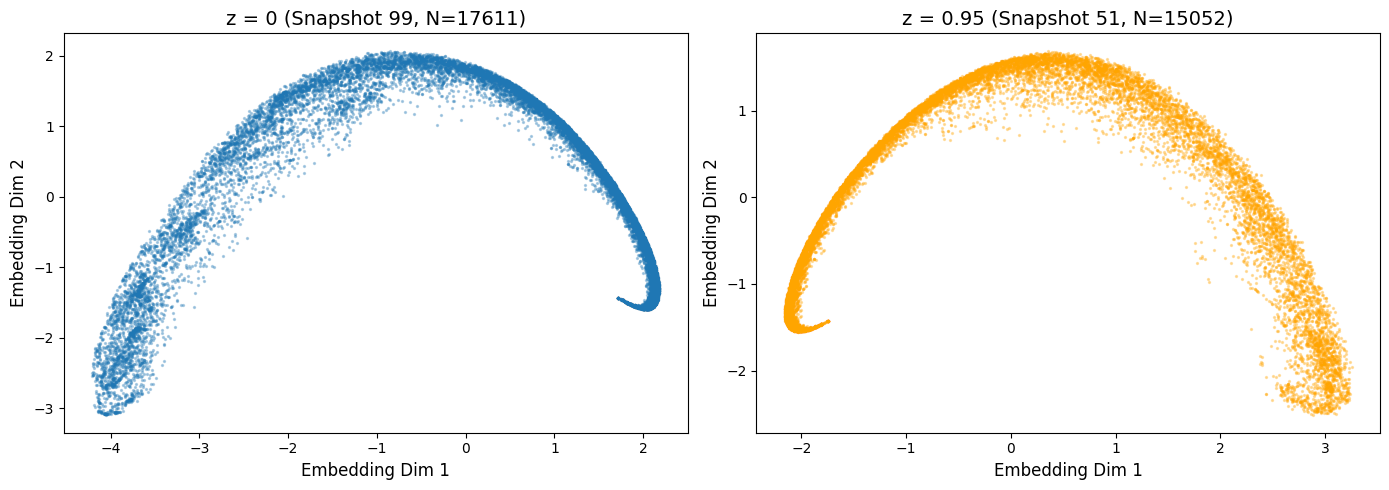

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# z=0 embedding
ax = axes[0]
ax.scatter(embedding_z0[:, 0], embedding_z0[:, 1], s=2, alpha=0.3)
ax.set_xlabel('Embedding Dim 1', fontsize=12)
ax.set_ylabel('Embedding Dim 2', fontsize=12)
ax.set_title(f'z = 0 (Snapshot 99, N={len(embedding_z0)})', fontsize=14)

# z=0.95 embedding
ax = axes[1]
ax.scatter(embedding_z1[:, 0], embedding_z1[:, 1], s=2, alpha=0.3, color='orange')
ax.set_xlabel('Embedding Dim 1', fontsize=12)
ax.set_ylabel('Embedding Dim 2', fontsize=12)
ax.set_title(f'z = 0.95 (Snapshot 51, N={len(embedding_z1)})', fontsize=14)

plt.tight_layout()
plt.show()

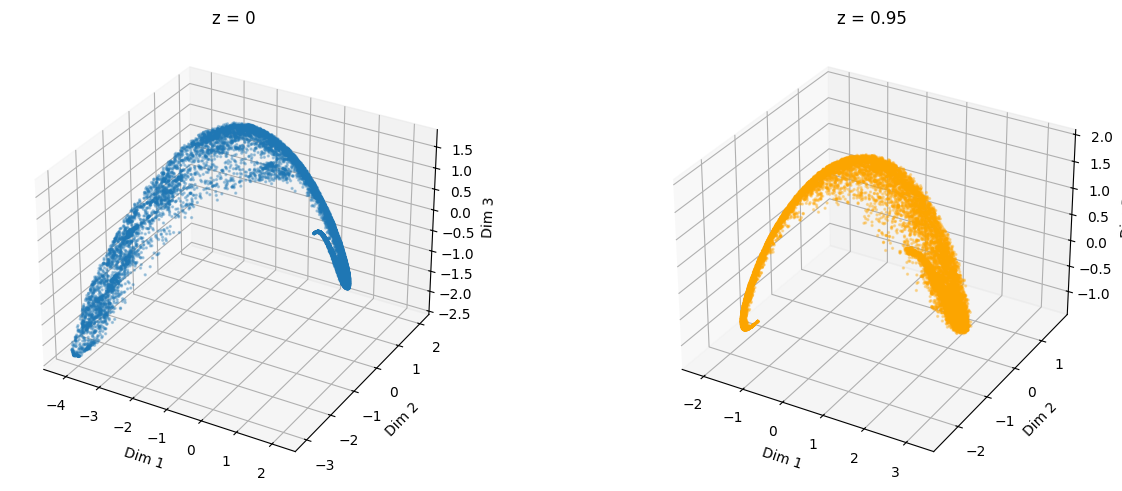

In [16]:
# 3D plot of embeddings
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(embedding_z0[:, 0], embedding_z0[:, 1], embedding_z0[:, 2], s=2, alpha=0.3)
ax1.set_xlabel('Dim 1')
ax1.set_ylabel('Dim 2')
ax1.set_zlabel('Dim 3')
ax1.set_title('z = 0')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(embedding_z1[:, 0], embedding_z1[:, 1], embedding_z1[:, 2], s=2, alpha=0.3, color='orange')
ax2.set_xlabel('Dim 1')
ax2.set_ylabel('Dim 2')
ax2.set_zlabel('Dim 3')
ax2.set_title('z = 0.95')

plt.tight_layout()
plt.show()

## Overlay Embeddings (Before Alignment)

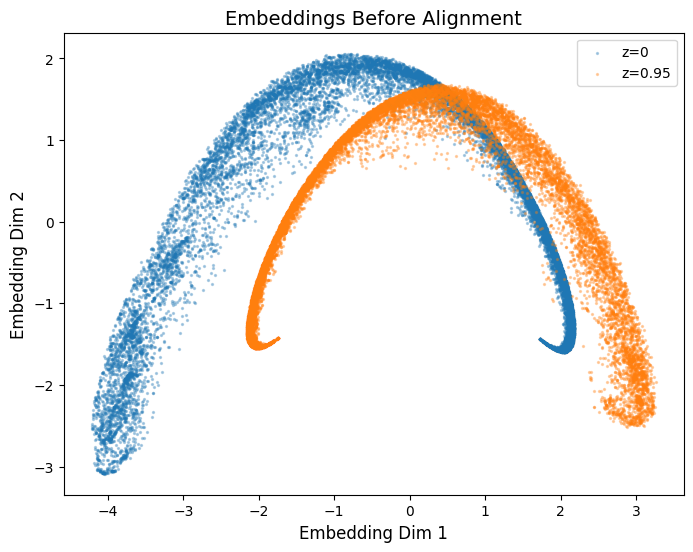

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(embedding_z0[:, 0], embedding_z0[:, 1], s=2, alpha=0.3, label='z=0')
plt.scatter(embedding_z1[:, 0], embedding_z1[:, 1], s=2, alpha=0.3, label='z=0.95')
plt.xlabel('Embedding Dim 1', fontsize=12)
plt.ylabel('Embedding Dim 2', fontsize=12)
plt.title('Embeddings Before Alignment', fontsize=14)
plt.legend()
plt.show()

In [18]:
# Load sorted neighbor vectors for neighborhood similarity cost
sorted_neighbors_z0 = data_z0['sorted_neighbors']
sorted_neighbors_z1 = data_z1['sorted_neighbors']

print(f"Sorted neighbors z=0 shape: {sorted_neighbors_z0.shape}")
print(f"Sorted neighbors z=0.95 shape: {sorted_neighbors_z1.shape}")

Sorted neighbors z=0 shape: (17611, 17611)
Sorted neighbors z=0.95 shape: (15052, 15052)


## Optimal Transport Alignment

In [19]:
def cost_matrix_neighborhoods(sorted_distance_vectors1, sorted_distance_vectors2):
    """
    Compute cost matrix based on neighborhood similarity.
    Uses Euclidean distance between sorted distance vectors.
    """
    num_vectors1 = len(sorted_distance_vectors1[0])
    num_vectors2 = len(sorted_distance_vectors2[0])

    # Match dimensions by using the smaller number of neighbors
    if num_vectors1 >= num_vectors2:
        similarity_distances = euclidean_distances(
            sorted_distance_vectors1[:, -num_vectors2:], 
            sorted_distance_vectors2
        )
    else:
        similarity_distances = euclidean_distances(
            sorted_distance_vectors1, 
            sorted_distance_vectors2[:, -num_vectors1:]
        )
    
    return similarity_distances

In [ ]:
def align_latent_spaces(embedding1, embedding2, sorted_vectors1, sorted_vectors2, 
                        reg=0.01, cost_type='neighborhood', normalize=True, 
                        return_both_directions=True):
    """
    Align latent spaces between two datasets using optimal transport.
    
    Parameters:
    -----------
    embedding1 : ndarray, shape (n1, d)
        Embedding of dataset 1
    embedding2 : ndarray, shape (n2, d)
        Embedding of dataset 2
    sorted_vectors1 : ndarray, shape (n1, k1)
        Sorted distance vectors for dataset 1
    sorted_vectors2 : ndarray, shape (n2, k2)
        Sorted distance vectors for dataset 2
    reg : float, default=0.01
        Entropy regularization parameter for Sinkhorn
    cost_type : str, default='neighborhood'
        'neighborhood' or 'euclidean'
    normalize : bool, default=True
        Whether to center and normalize embeddings
    return_both_directions : bool, default=True
        If True, returns both directions of alignment
    
    Returns:
    --------
    dict with alignment results
    """
    # Convert to real and take first 3 dimensions
    e1 = np.real(embedding1[:, :3])
    e2 = np.real(embedding2[:, :3])
    
    # Step 1: Center and normalize embeddings
    if normalize:
        e1_centered = e1 - e1.mean(axis=0)
        e2_centered = e2 - e2.mean(axis=0)
        e1_norm = e1_centered / np.linalg.norm(e1_centered, 'fro')
        e2_norm = e2_centered / np.linalg.norm(e2_centered, 'fro')
    else:
        e1_norm = e1
        e2_norm = e2
    
    # Step 2: Compute cost matrix
    if cost_type == 'neighborhood':
        C = cost_matrix_neighborhoods(sorted_vectors1, sorted_vectors2)
        C = C / np.linalg.norm(C, 'fro')
        C = C ** 2
    elif cost_type == 'euclidean':
        C = ot.dist(e1_norm, e2_norm, metric='sqeuclidean')
    else:
        raise ValueError(f"cost_type must be 'neighborhood' or 'euclidean'")
    
    # Normalize cost matrix for numerical stability
    C_normalized = C / C.max()
    
    # Step 3: Uniform weights
    a = ot.utils.unif(len(e1_norm))
    b = ot.utils.unif(len(e2_norm))
    
    # Step 4: Solve OT with Sinkhorn
    print(f"Running Sinkhorn with reg={reg}, cost_type='{cost_type}'")
    print(f"Cost matrix: shape={C.shape}, min={C.min():.2e}, max={C.max():.2e}")
    
    P = ot.sinkhorn(a, b, M=C_normalized, reg=reg, numItermax=50000, warn=True)
    
    # Step 5: Transport embeddings using barycentric projection
    P_row_normalized = P / P.sum(axis=1, keepdims=True)
    e1_aligned = P_row_normalized @ e2_norm
    
    result = {
        'e1_aligned': e1_aligned,
        'e1_norm': e1_norm,
        'e2_norm': e2_norm,
        'P': P,
        'cost_matrix': C,
    }
    
    if return_both_directions:
        P_col_normalized = P.T / P.T.sum(axis=1, keepdims=True)
        e2_aligned = P_col_normalized @ e1_norm
        result['e2_aligned'] = e2_aligned
    
    print(f"Alignment complete. Transport plan shape: {P.shape}")
    
    return result

In [21]:
# Run alignment (z=0.95 -> z=0)
# This aligns the z=0.95 embedding into the z=0 embedding space
result = align_latent_spaces(
    embedding_z0, embedding_z1,
    sorted_neighbors_z0, sorted_neighbors_z1,
    reg=1e-3,
    cost_type='neighborhood'
)

e_z0_norm = result['e1_norm']
e_z1_aligned = result['e2_aligned']  # z=0.95 transported to z=0 space
P = result['P']

Running Sinkhorn with reg=0.001, cost_type='neighborhood'
Cost matrix: shape=(17611, 15052), min=0.000000, max=0.000000
Alignment complete. Transport plan shape: (17611, 15052)


## Visualize Alignment Results

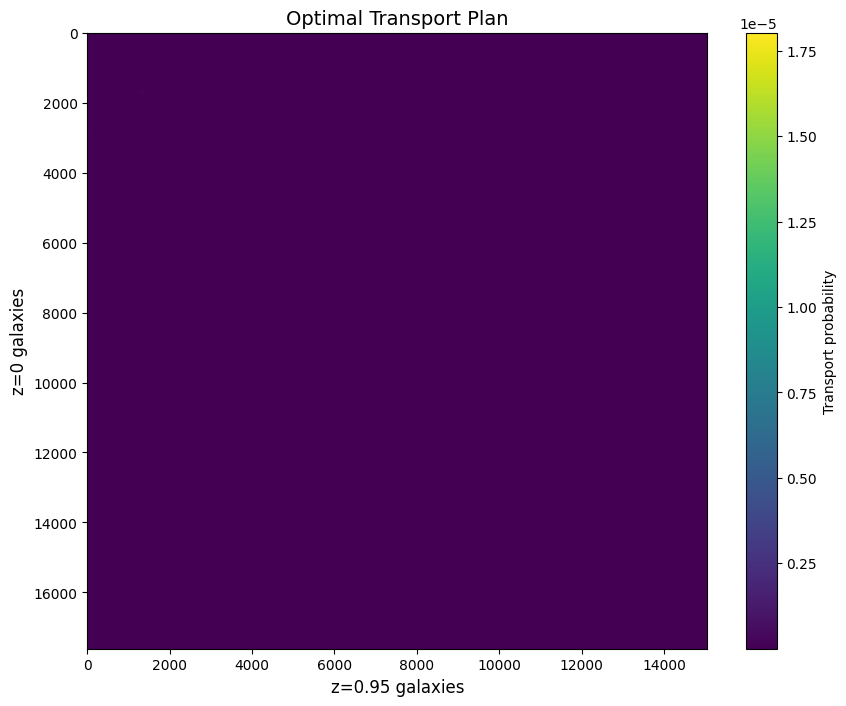

In [22]:
# Visualize transport plan
plt.figure(figsize=(10, 8))
plt.imshow(P, aspect='auto', vmin=1e-10)
plt.colorbar(label='Transport probability')
plt.xlabel('z=0.95 galaxies', fontsize=12)
plt.ylabel('z=0 galaxies', fontsize=12)
plt.title('Optimal Transport Plan', fontsize=14)
plt.show()

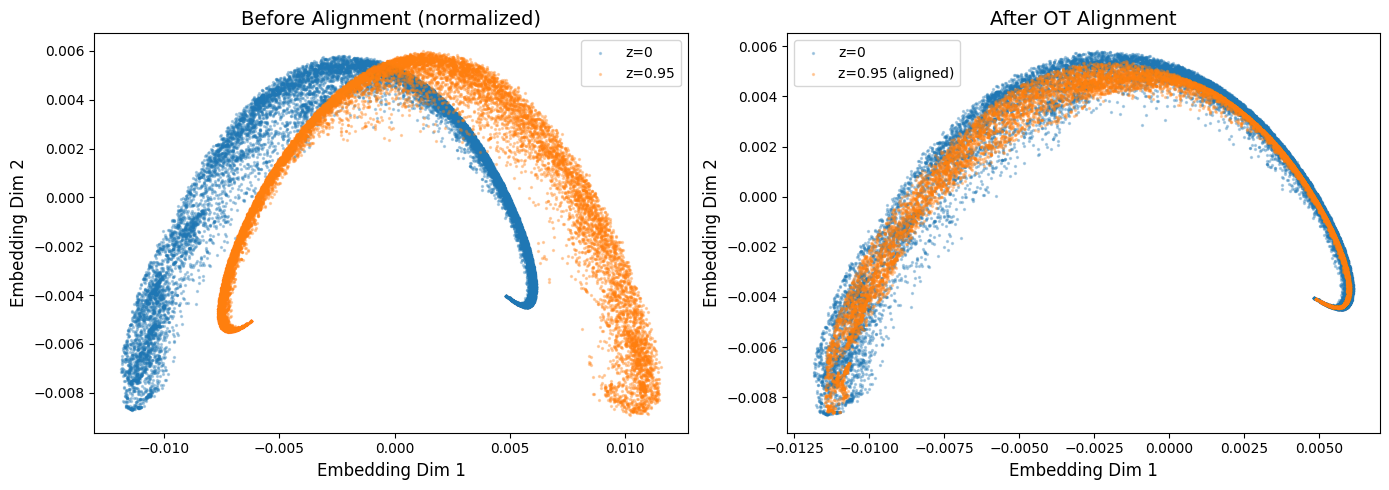

In [23]:
# Compare embeddings before and after alignment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before alignment (normalized embeddings)
ax = axes[0]
ax.scatter(e_z0_norm[:, 0], e_z0_norm[:, 1], s=2, alpha=0.3, label='z=0')
e_z1_norm = result['e2_norm']
ax.scatter(e_z1_norm[:, 0], e_z1_norm[:, 1], s=2, alpha=0.3, label='z=0.95')
ax.set_xlabel('Embedding Dim 1', fontsize=12)
ax.set_ylabel('Embedding Dim 2', fontsize=12)
ax.set_title('Before Alignment (normalized)', fontsize=14)
ax.legend()

# After alignment
ax = axes[1]
ax.scatter(e_z0_norm[:, 0], e_z0_norm[:, 1], s=2, alpha=0.3, label='z=0')
ax.scatter(e_z1_aligned[:, 0], e_z1_aligned[:, 1], s=2, alpha=0.3, label='z=0.95 (aligned)')
ax.set_xlabel('Embedding Dim 1', fontsize=12)
ax.set_ylabel('Embedding Dim 2', fontsize=12)
ax.set_title('After OT Alignment', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

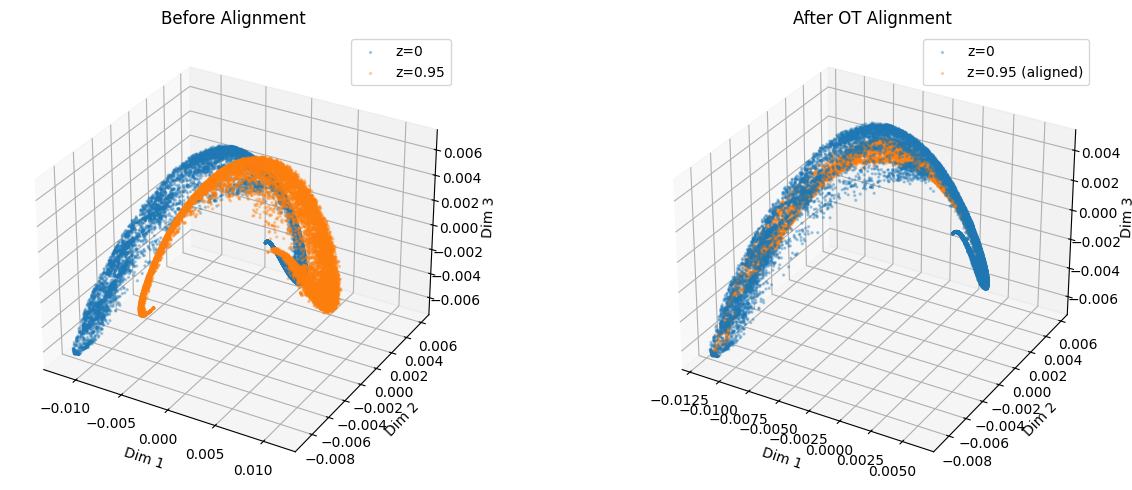

In [24]:
# 3D visualization of aligned embeddings
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(e_z0_norm[:, 0], e_z0_norm[:, 1], e_z0_norm[:, 2], s=2, alpha=0.3, label='z=0')
ax1.scatter(e_z1_norm[:, 0], e_z1_norm[:, 1], e_z1_norm[:, 2], s=2, alpha=0.3, label='z=0.95')
ax1.set_xlabel('Dim 1')
ax1.set_ylabel('Dim 2')
ax1.set_zlabel('Dim 3')
ax1.set_title('Before Alignment')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(e_z0_norm[:, 0], e_z0_norm[:, 1], e_z0_norm[:, 2], s=2, alpha=0.3, label='z=0')
ax2.scatter(e_z1_aligned[:, 0], e_z1_aligned[:, 1], e_z1_aligned[:, 2], s=2, alpha=0.3, label='z=0.95 (aligned)')
ax2.set_xlabel('Dim 1')
ax2.set_ylabel('Dim 2')
ax2.set_zlabel('Dim 3')
ax2.set_title('After OT Alignment')
ax2.legend()

plt.tight_layout()
plt.show()

## Track Galaxies Across Redshifts Using Merger Trees

In [25]:
import requests

# TNG API configuration
# Get your API key from: https://www.tng-project.org/users/profile/
API_KEY = "e51de6c190e7b29e4c4d27f191fb6f40"  # Replace with your actual API key

# Use https and correct simulation name (no trailing slash)
base_url = "https://www.tng-project.org/api/TNG100-1"

# Snapshot numbers
SNAP_Z0 = 99      # z ≈ 0
SNAP_Z095 = 51    # z ≈ 0.95

In [26]:
def find_progenitor_at_snapshot_api(subfind_id, snap_descendant, snap_target, debug=False):
    """
    Find the main progenitor of a galaxy at a target snapshot using TNG web API.
    
    Parameters:
    -----------
    subfind_id : int
        SubfindID of the descendant galaxy
    snap_descendant : int
        Snapshot number of the descendant galaxy
    snap_target : int
        Target snapshot to find progenitor at
    debug : bool
        Print debug information
        
    Returns:
    --------
    int or None
        SubfindID of the progenitor at snap_target, or None if not found
    """
    url = f"{base_url}/snapshots/{snap_descendant}/subhalos/{subfind_id}/sublink/simple.json"
    headers = {"api-key": API_KEY}
    
    try:
        response = requests.get(url, headers=headers)
        
        if response.status_code != 200:
            if debug:
                print(f"    DEBUG: API returned status {response.status_code}")
            return None
        
        if 'application/json' not in response.headers.get('Content-Type', ''):
            if debug:
                print(f"    DEBUG: Did not get JSON response")
            return None
        
        data = response.json()
        
        # Data structure: {'Main': [[snap, subfind], ...], 'Mergers': [...]}
        if 'Main' not in data:
            if debug:
                print(f"    DEBUG: No 'Main' branch in response")
            return None
        
        main = data['Main']
        
        if not isinstance(main, list) or len(main) == 0:
            if debug:
                print(f"    DEBUG: Main branch is empty or not a list")
            return None
        
        # Main is a list of [SnapNum, SubfindID] pairs
        snaps = [entry[0] for entry in main]
        subfind_ids = [entry[1] for entry in main]
        
        if snap_target not in snaps:
            if debug:
                print(f"    DEBUG: snap {snap_target} not in tree (range: {min(snaps)}-{max(snaps)})")
            return None
        
        idx = snaps.index(snap_target)
        return int(subfind_ids[idx])
    
    except Exception as e:
        if debug:
            print(f"    DEBUG: Exception: {type(e).__name__}: {e}")
        return None

In [136]:
# Look up progenitors for 20 sample galaxies
NUM_SAMPLE =  20

print(f"Looking up progenitors for {NUM_SAMPLE} galaxies...")
print(f"Finding matches from snapshot {SNAP_Z0} (z≈0) to snapshot {SNAP_Z095} (z≈0.95)")
print()

# We need to find: for each z=0 galaxy, what is its progenitor at z=0.95?
# And then find the index of that progenitor in our z=0.95 embedding

# Create a lookup table for z=0.95 SubfindIDs -> embedding indices
subfind_to_idx_z1 = {int(sid): idx for idx, sid in enumerate(original_index_z1)}

matched_pairs = []
# for i in range(NUM_SAMPLE):
for i in np.random.choice(len(original_index_z0), NUM_SAMPLE, replace=False):
    subfind_z0 = int(original_index_z0[i])
    
    # Find progenitor at z=0.95
    prog_subfind = find_progenitor_at_snapshot_api(subfind_z0, SNAP_Z0, SNAP_Z095, debug=False)
    
    if prog_subfind is None:
        print(f"  Galaxy {i}: SubfindID {subfind_z0} -> No progenitor found")
        continue
    
    # Check if this progenitor is in our z=0.95 embedding
    if prog_subfind not in subfind_to_idx_z1:
        print(f"  Galaxy {i}: SubfindID {subfind_z0} -> Progenitor {prog_subfind} not in embedding (filtered out)")
        continue
    
    idx_z1 = subfind_to_idx_z1[prog_subfind]
    
    print(f"  Galaxy {i}: SubfindID {subfind_z0} (z=0) <- {prog_subfind} (z=0.95, idx={idx_z1})")
    
    matched_pairs.append({
        'idx_z0': i,
        'idx_z1': idx_z1,
        'subfind_z0': subfind_z0,
        'subfind_z1': prog_subfind
    })

print()
print(f"Successfully matched {len(matched_pairs)} galaxy pairs")

# Create the progenitor map
progenitor_map = {
    'idx_z0': np.array([p['idx_z0'] for p in matched_pairs]),
    'idx_z1': np.array([p['idx_z1'] for p in matched_pairs]),
    'subfind_z0': np.array([p['subfind_z0'] for p in matched_pairs]),
    'subfind_z1': np.array([p['subfind_z1'] for p in matched_pairs])
}

Looking up progenitors for 20 galaxies...
Finding matches from snapshot 99 (z≈0) to snapshot 51 (z≈0.95)

  Galaxy 5759: SubfindID 374384 (z=0) <- 425967 (z=0.95, idx=11268)
  Galaxy 15363: SubfindID 622110 (z=0) <- 492841 (z=0.95, idx=14488)
  Galaxy 10108: SubfindID 538179 (z=0) <- 426853 (z=0.95, idx=11318)
  Galaxy 6879: SubfindID 430471 -> Progenitor 536834 not in embedding (filtered out)
  Galaxy 5743: SubfindID 373700 (z=0) <- 392156 (z=0.95, idx=9514)
  Galaxy 16067: SubfindID 632515 -> Progenitor 581238 not in embedding (filtered out)
  Galaxy 17432: SubfindID 676812 -> Progenitor 554608 not in embedding (filtered out)
  Galaxy 5962: SubfindID 385350 (z=0) <- 287728 (z=0.95, idx=5690)
  Galaxy 4613: SubfindID 305085 (z=0) <- 434392 (z=0.95, idx=11733)
  Galaxy 13402: SubfindID 595674 (z=0) <- 455971 (z=0.95, idx=12962)
  Galaxy 13703: SubfindID 599904 -> Progenitor 497979 not in embedding (filtered out)
  Galaxy 17457: SubfindID 679600 (z=0) <- 463641 (z=0.95, idx=13364)
  Gal

In [137]:
def get_paired_embeddings(progenitor_map, e_z0_norm, e_z1_aligned):
    """
    Get paired embedding coordinates for matched galaxies.
    Both embeddings are in the aligned (z=0) space, so they are directly comparable.
    """
    idx_z0 = progenitor_map['idx_z0']
    idx_z1 = progenitor_map['idx_z1']
    
    coords_z0 = e_z0_norm[idx_z0]
    coords_z095 = e_z1_aligned[idx_z1]
    
    return {
        'coords_z0': coords_z0,
        'coords_z095': coords_z095,
        'idx_z0': idx_z0,
        'idx_z1': idx_z1,
        'subfind_z0': progenitor_map['subfind_z0'],
        'subfind_z1': progenitor_map['subfind_z1']
    }

In [138]:
# Get paired embeddings in aligned space
paired = get_paired_embeddings(progenitor_map, e_z0_norm, e_z1_aligned)

print(f"Number of matched galaxy pairs: {len(paired['coords_z0'])}")
print(f"Coords at z=0 shape: {paired['coords_z0'].shape}")
print(f"Coords at z=0.95 (aligned) shape: {paired['coords_z095'].shape}")

Number of matched galaxy pairs: 14
Coords at z=0 shape: (14, 3)
Coords at z=0.95 (aligned) shape: (14, 3)


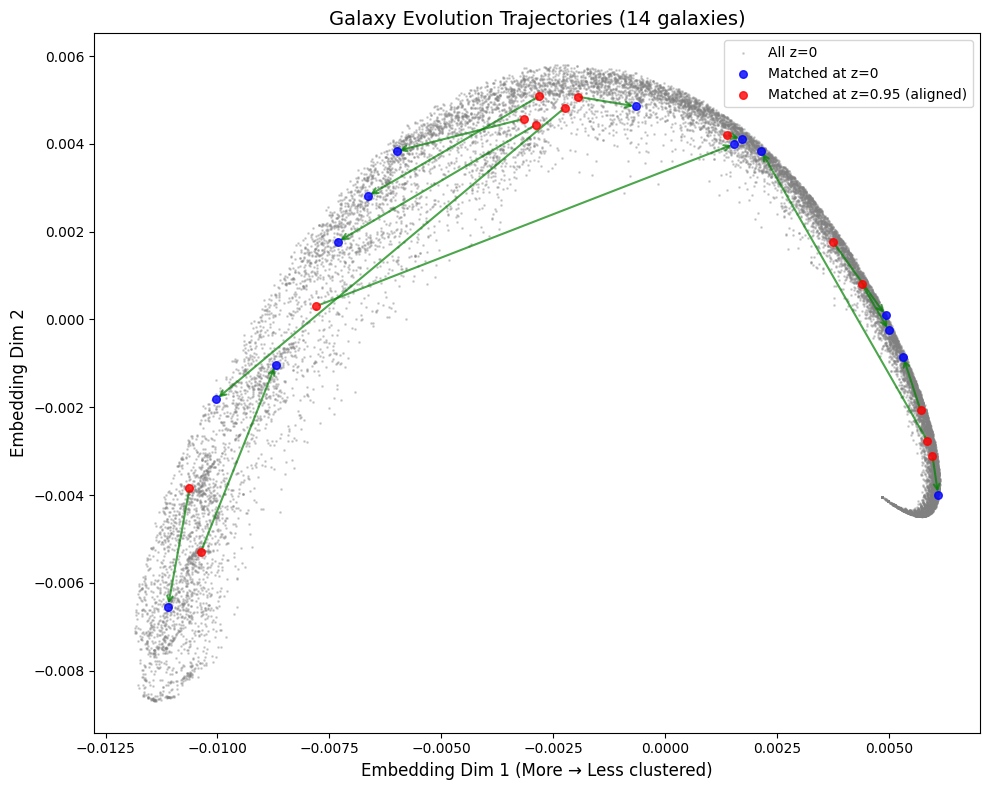

In [144]:
# Visualize galaxy trajectories in embedding space
# Each arrow connects a galaxy's position at z=0.95 to its position at z=0

fig, ax = plt.subplots(figsize=(10, 8))

# Plot all galaxies as background
ax.scatter(e_z0_norm[:, 0], e_z0_norm[:, 1], s=1, alpha=0.3, c='gray', label='All z=0')

# Plot matched galaxies
ax.scatter(paired['coords_z0'][:, 0], paired['coords_z0'][:, 1], 
           s=30, alpha=0.8, c='blue', label='Matched at z=0', zorder=5)
ax.scatter(paired['coords_z095'][:, 0], paired['coords_z095'][:, 1], 
           s=30, alpha=0.8, c='red', label='Matched at z=0.95 (aligned)', zorder=5)

# Draw arrows from z=0.95 to z=0 for all matched galaxies
for i in range(len(paired['coords_z0'])):
    ax.annotate('', 
                xy=paired['coords_z0'][i, :2],
                xytext=paired['coords_z095'][i, :2],
                arrowprops=dict(arrowstyle='->', color='green', alpha=0.7, lw=1.5))

ax.set_xlabel('Embedding Dim 1 (More '+u"\u2192"+' Less clustered)', fontsize=12)
ax.set_ylabel('Embedding Dim 2', fontsize=12)
ax.set_title(f'Galaxy Evolution Trajectories ({len(paired["coords_z0"])} galaxies)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

Displacement statistics:
  Mean: 0.004607
  Std: 0.003329
  Median: 0.004345
  Max: 0.010949


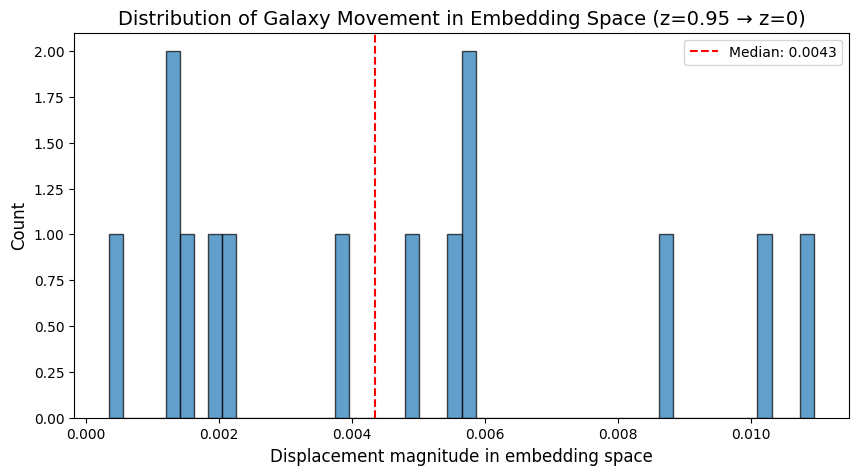

In [140]:
# Compute displacement vectors (movement in embedding space from z=0.95 to z=0)
displacement = paired['coords_z0'] - paired['coords_z095']
displacement_magnitude = np.linalg.norm(displacement, axis=1)

print(f"Displacement statistics:")
print(f"  Mean: {displacement_magnitude.mean():.6f}")
print(f"  Std: {displacement_magnitude.std():.6f}")
print(f"  Median: {np.median(displacement_magnitude):.6f}")
print(f"  Max: {displacement_magnitude.max():.6f}")

# Histogram of displacement magnitudes
plt.figure(figsize=(10, 5))
plt.hist(displacement_magnitude, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Displacement magnitude in embedding space', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Galaxy Movement in Embedding Space (z=0.95 → z=0)', fontsize=14)
plt.axvline(np.median(displacement_magnitude), color='red', linestyle='--', label=f'Median: {np.median(displacement_magnitude):.4f}')
plt.legend()
plt.show()

## Displacement vs. Galaxy Properties

In [118]:
# Fetch galaxy properties at z=0 for matched galaxies
print("Fetching galaxy properties from TNG API (z=0)...")

sfr_z0 = []
subhalo_mass_z0 = []
star_metallicity_z0 = []
headers = {"api-key": API_KEY}

for i, subfind_id in enumerate(paired['subfind_z0']):  # Use z=0 SubfindIDs
    url = f"{base_url}/snapshots/{SNAP_Z0}/subhalos/{int(subfind_id)}"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200 and 'application/json' in response.headers.get('Content-Type', ''):
        data = response.json()
        sfr = data.get('sfr', np.nan)
        mass = data.get('mass', np.nan)
        metallicity = data.get('starmetallicity', np.nan)
        
        sfr_z0.append(sfr)
        subhalo_mass_z0.append(mass)
        star_metallicity_z0.append(metallicity)
        print(f"  Galaxy {i}: SubfindID {subfind_id}, SFR={sfr:.3f}, Mass={mass:.2e}, Z*={metallicity:.4f}")
    else:
        sfr_z0.append(np.nan)
        subhalo_mass_z0.append(np.nan)
        star_metallicity_z0.append(np.nan)
        print(f"  Galaxy {i}: SubfindID {subfind_id} - failed to fetch")

sfr_z0 = np.array(sfr_z0)
subhalo_mass_z0 = np.array(subhalo_mass_z0)
star_metallicity_z0 = np.array(star_metallicity_z0)

print(f"\nFetched properties for {np.sum(~np.isnan(sfr_z0))} galaxies")

Fetching galaxy properties from TNG API (z=0)...
  Galaxy 0: SubfindID 558955, SFR=2.827, Mass=3.60e+01, Z*=0.0180
  Galaxy 1: SubfindID 275538, SFR=0.051, Mass=3.52e+00, Z*=0.0204
  Galaxy 2: SubfindID 168407, SFR=0.300, Mass=6.81e+00, Z*=0.0161
  Galaxy 3: SubfindID 265942, SFR=0.000, Mass=9.77e-01, Z*=0.0191
  Galaxy 4: SubfindID 587151, SFR=0.273, Mass=2.49e+01, Z*=0.0168
  Galaxy 5: SubfindID 693623, SFR=0.022, Mass=5.42e+00, Z*=0.0147
  Galaxy 6: SubfindID 605252, SFR=0.298, Mass=1.95e+01, Z*=0.0182
  Galaxy 7: SubfindID 399520, SFR=0.053, Mass=3.03e+02, Z*=0.0239
  Galaxy 8: SubfindID 354487, SFR=0.662, Mass=1.30e+01, Z*=0.0145
  Galaxy 9: SubfindID 531151, SFR=0.208, Mass=5.48e+01, Z*=0.0204
  Galaxy 10: SubfindID 621675, SFR=0.329, Mass=1.52e+01, Z*=0.0145
  Galaxy 11: SubfindID 590062, SFR=0.774, Mass=2.33e+01, Z*=0.0187
  Galaxy 12: SubfindID 56, SFR=0.000, Mass=2.04e+01, Z*=0.0225
  Galaxy 13: SubfindID 192918, SFR=0.318, Mass=3.00e+00, Z*=0.0235
  Galaxy 14: SubfindID 4418

In [119]:
# Fetch galaxy properties (SFR, mass, metallicity) at z=0.95 for matched galaxies
print("Fetching galaxy properties from TNG API (z=0.95)...")

sfr_z095 = []
subhalo_mass_z095 = []
star_metallicity_z095 = []
headers = {"api-key": API_KEY}

for i, subfind_id in enumerate(paired['subfind_z1']):  # Use z=0.95 SubfindIDs
    url = f"{base_url}/snapshots/{SNAP_Z095}/subhalos/{int(subfind_id)}"
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200 and 'application/json' in response.headers.get('Content-Type', ''):
        data = response.json()
        sfr = data.get('sfr', np.nan)
        mass = data.get('mass', np.nan)  # Total subhalo mass in 10^10 Msun/h
        metallicity = data.get('starmetallicity', np.nan)  # Star metallicity (mass fraction)
        
        sfr_z095.append(sfr)
        subhalo_mass_z095.append(mass)
        star_metallicity_z095.append(metallicity)
        print(f"  Galaxy {i}: SubfindID {subfind_id}, SFR={sfr:.3f}, Mass={mass:.2e}, Z*={metallicity:.4f}")
    else:
        sfr_z095.append(np.nan)
        subhalo_mass_z095.append(np.nan)
        star_metallicity_z095.append(np.nan)
        print(f"  Galaxy {i}: SubfindID {subfind_id} - failed to fetch")

sfr_z095 = np.array(sfr_z095)
subhalo_mass_z095 = np.array(subhalo_mass_z095)
star_metallicity_z095 = np.array(star_metallicity_z095)

print(f"\nFetched properties for {np.sum(~np.isnan(sfr_z095))} galaxies")

Fetching galaxy properties from TNG API (z=0.95)...
  Galaxy 0: SubfindID 419584, SFR=1.817, Mass=2.25e+01, Z*=0.0106
  Galaxy 1: SubfindID 125383, SFR=2.565, Mass=1.48e+01, Z*=0.0129
  Galaxy 2: SubfindID 511161, SFR=0.448, Mass=9.29e+00, Z*=0.0092
  Galaxy 3: SubfindID 468793, SFR=1.506, Mass=1.40e+01, Z*=0.0144
  Galaxy 4: SubfindID 444975, SFR=2.544, Mass=1.49e+01, Z*=0.0077
  Galaxy 5: SubfindID 471365, SFR=0.435, Mass=1.17e+01, Z*=0.0099
  Galaxy 6: SubfindID 458967, SFR=0.744, Mass=1.52e+01, Z*=0.0133
  Galaxy 7: SubfindID 203330, SFR=8.119, Mass=1.48e+02, Z*=0.0262
  Galaxy 8: SubfindID 457069, SFR=1.363, Mass=1.32e+01, Z*=0.0105
  Galaxy 9: SubfindID 412190, SFR=1.493, Mass=2.50e+01, Z*=0.0188
  Galaxy 10: SubfindID 495899, SFR=0.286, Mass=1.10e+01, Z*=0.0094
  Galaxy 11: SubfindID 458441, SFR=0.432, Mass=1.51e+01, Z*=0.0117
  Galaxy 12: SubfindID 370822, SFR=2.260, Mass=3.66e+01, Z*=0.0206
  Galaxy 13: SubfindID 149097, SFR=1.400, Mass=7.82e+00, Z*=0.0120
  Galaxy 14: Subfind

In [120]:
# Compute change in galaxy properties (z=0 - z=0.95)
delta_sfr = sfr_z0 - sfr_z095
delta_mass = subhalo_mass_z0 - subhalo_mass_z095  # in 10^10 Msun/h
delta_metallicity = star_metallicity_z0 - star_metallicity_z095

# Also compute log ratios for mass (more meaningful for large dynamic range)
mass_ratio = subhalo_mass_z0 / subhalo_mass_z095
log_mass_ratio = np.log10(mass_ratio)

sfr_ratio = sfr_z0/sfr_z095
log_sfr_ratio = np.log10(sfr_ratio)

print("Change in galaxy properties (z=0.95 → z=0):")
print(f"  Δ SFR: mean={np.nanmean(delta_sfr):.3f}, std={np.nanstd(delta_sfr):.3f}")
print(f"  Δ Mass: mean={np.nanmean(delta_mass):.2e}, std={np.nanstd(delta_mass):.2e}")
print(f"  log(M_z0/M_z095): mean={np.nanmean(log_mass_ratio):.3f}, std={np.nanstd(log_mass_ratio):.3f}")
print(f"  Δ Z*: mean={np.nanmean(delta_metallicity):.4f}, std={np.nanstd(delta_metallicity):.4f}")

Change in galaxy properties (z=0.95 → z=0):
  Δ SFR: mean=-2.597, std=5.424
  Δ Mass: mean=5.20e+01, std=3.06e+02
  log(M_z0/M_z095): mean=-0.076, std=0.482
  Δ Z*: mean=0.0049, std=0.0041


/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_71642/1112986414.py:10: RuntimeWarning: invalid value encountered in divide
  sfr_ratio = sfr_z0/sfr_z095
/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_71642/1112986414.py:11: RuntimeWarning: divide by zero encountered in log10
  log_sfr_ratio = np.log10(sfr_ratio)


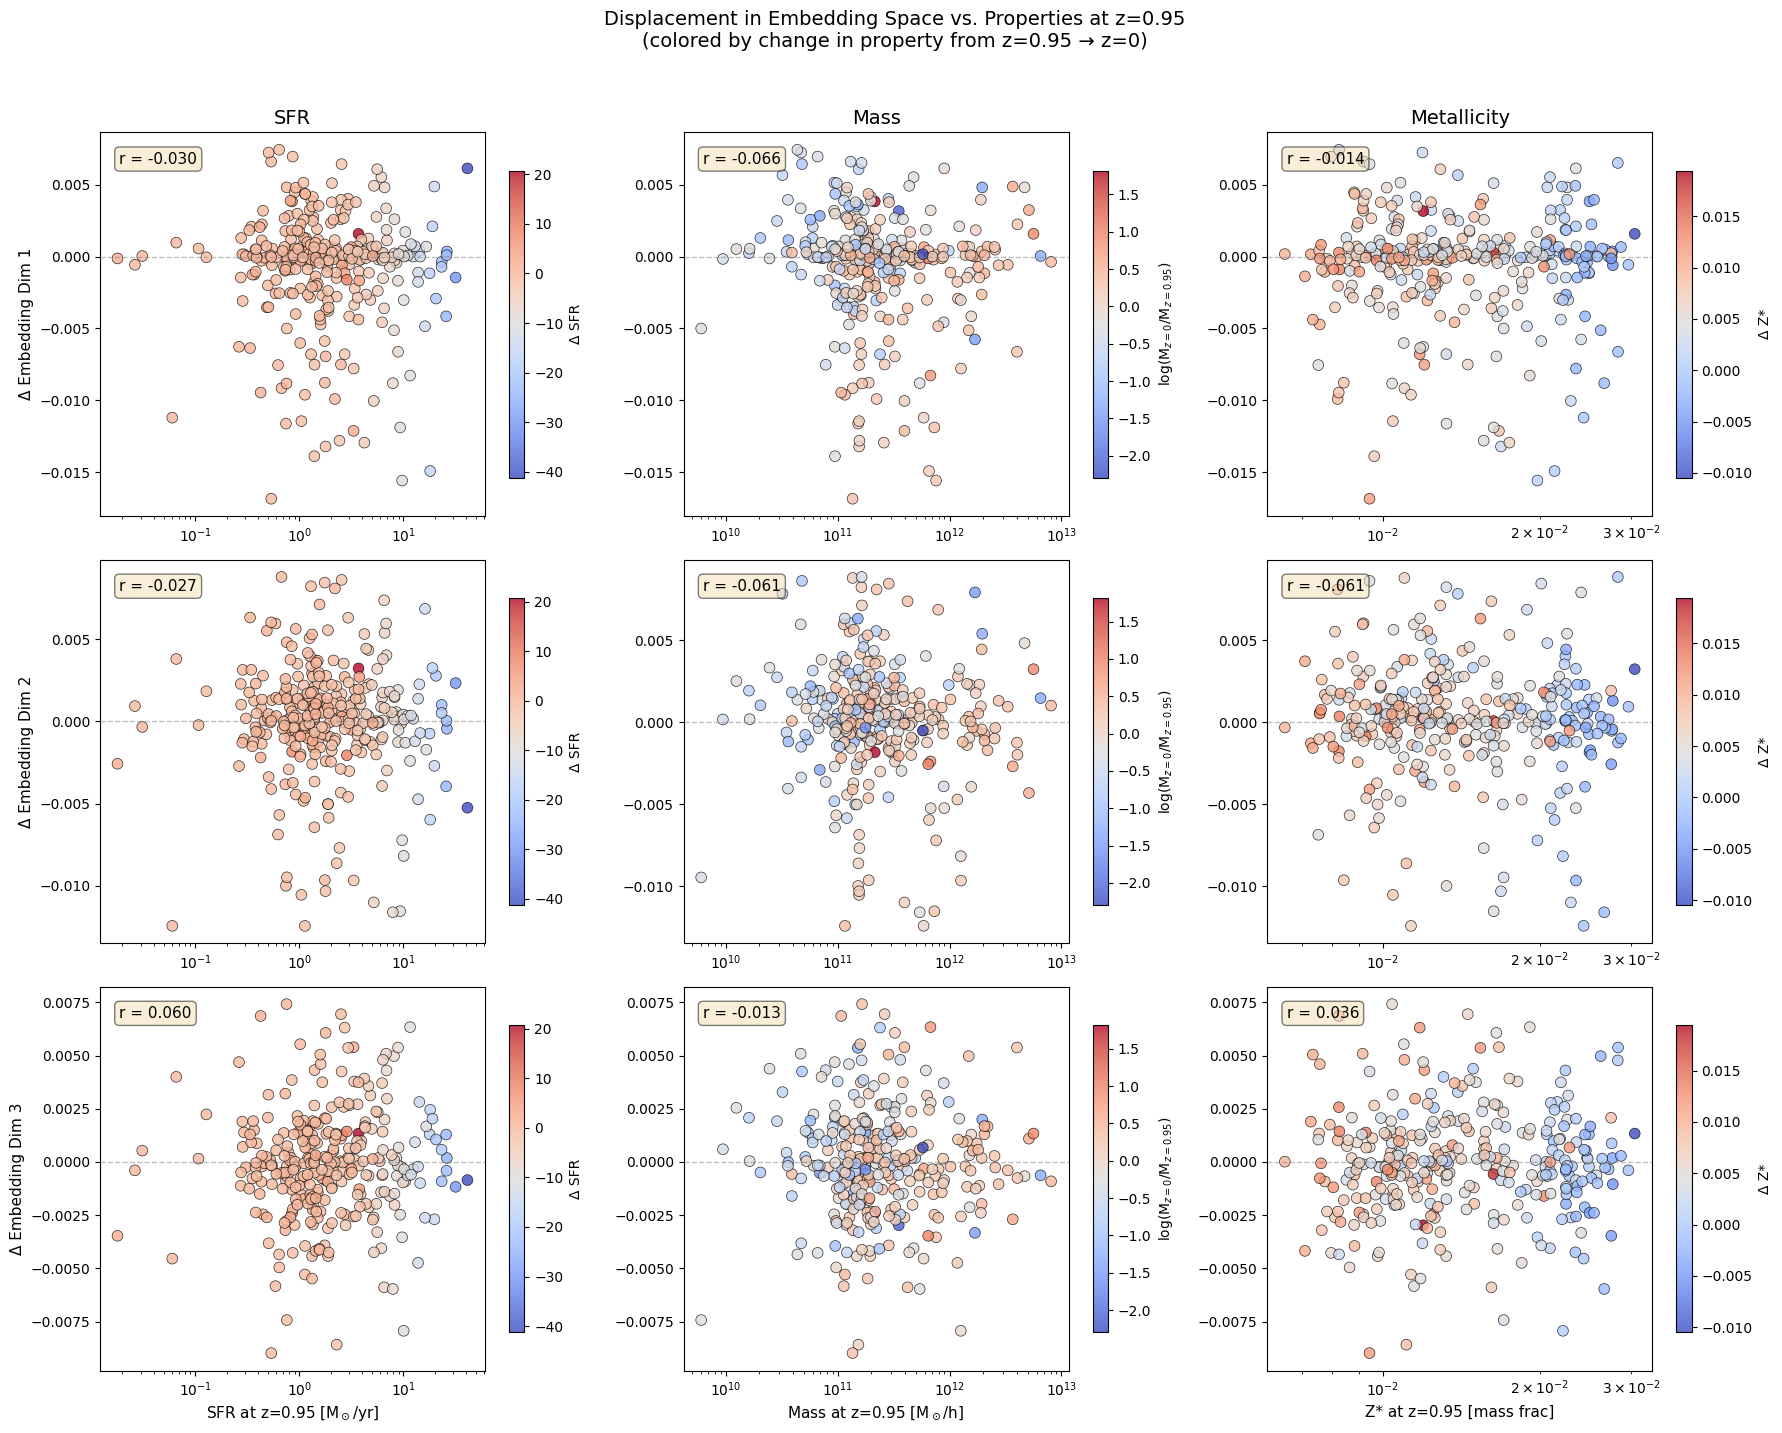

In [121]:
# Plot displacement along each embedding dimension vs. properties at z=0.95
# Colored by the CHANGE in that property (z=0 - z=0.95)
# Rows: embedding dimensions 1, 2, 3
# Columns: SFR, Mass, Metallicity

# Compute signed displacement along each dimension (z=0 - z=0.95)
displacement = paired['coords_z0'] - paired['coords_z095']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Properties: (name, x_values, x_label, color_values, color_label)
properties = [
    ('SFR', sfr_z095, 'SFR at z=0.95 [M$_\odot$/yr]', delta_sfr, 'Δ SFR'),
    ('Mass', subhalo_mass_z095 * 1e10, 'Mass at z=0.95 [M$_\odot$/h]', log_mass_ratio, 'log(M$_{z=0}$/M$_{z=0.95}$)'),
    ('Metallicity', star_metallicity_z095, 'Z* at z=0.95 [mass frac]', delta_metallicity, 'Δ Z*')
]

for row, dim in enumerate([0, 1, 2]):
    disp_dim = displacement[:, dim]
    
    for col, (prop_name, prop_vals, xlabel, color_vals, clabel) in enumerate(properties):
        ax = axes[row, col]
        
        valid = ~np.isnan(prop_vals) & (prop_vals > 0) & ~np.isnan(color_vals)
        
        sc = ax.scatter(prop_vals[valid], disp_dim[valid], s=60, alpha=0.8, 
                        c=color_vals[valid], cmap='coolwarm', edgecolors='k', linewidths=0.5)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xscale('log')
        ax.set_xlabel(xlabel if row == 2 else '', fontsize=11)
        ax.set_ylabel(f'Δ Embedding Dim {dim+1}' if col == 0 else '', fontsize=11)
        
        if row == 0:
            ax.set_title(prop_name, fontsize=14)
        
        # Add colorbar with label to ALL subplots
        cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
        cbar.set_label(clabel, fontsize=10)
        
        # Add correlation coefficient (displacement vs property)
        if np.sum(valid) > 2:
            corr = np.corrcoef(np.log10(prop_vals[valid]), disp_dim[valid])[0, 1]
            ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Displacement in Embedding Space vs. Properties at z=0.95\n(colored by change in property from z=0.95 → z=0)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

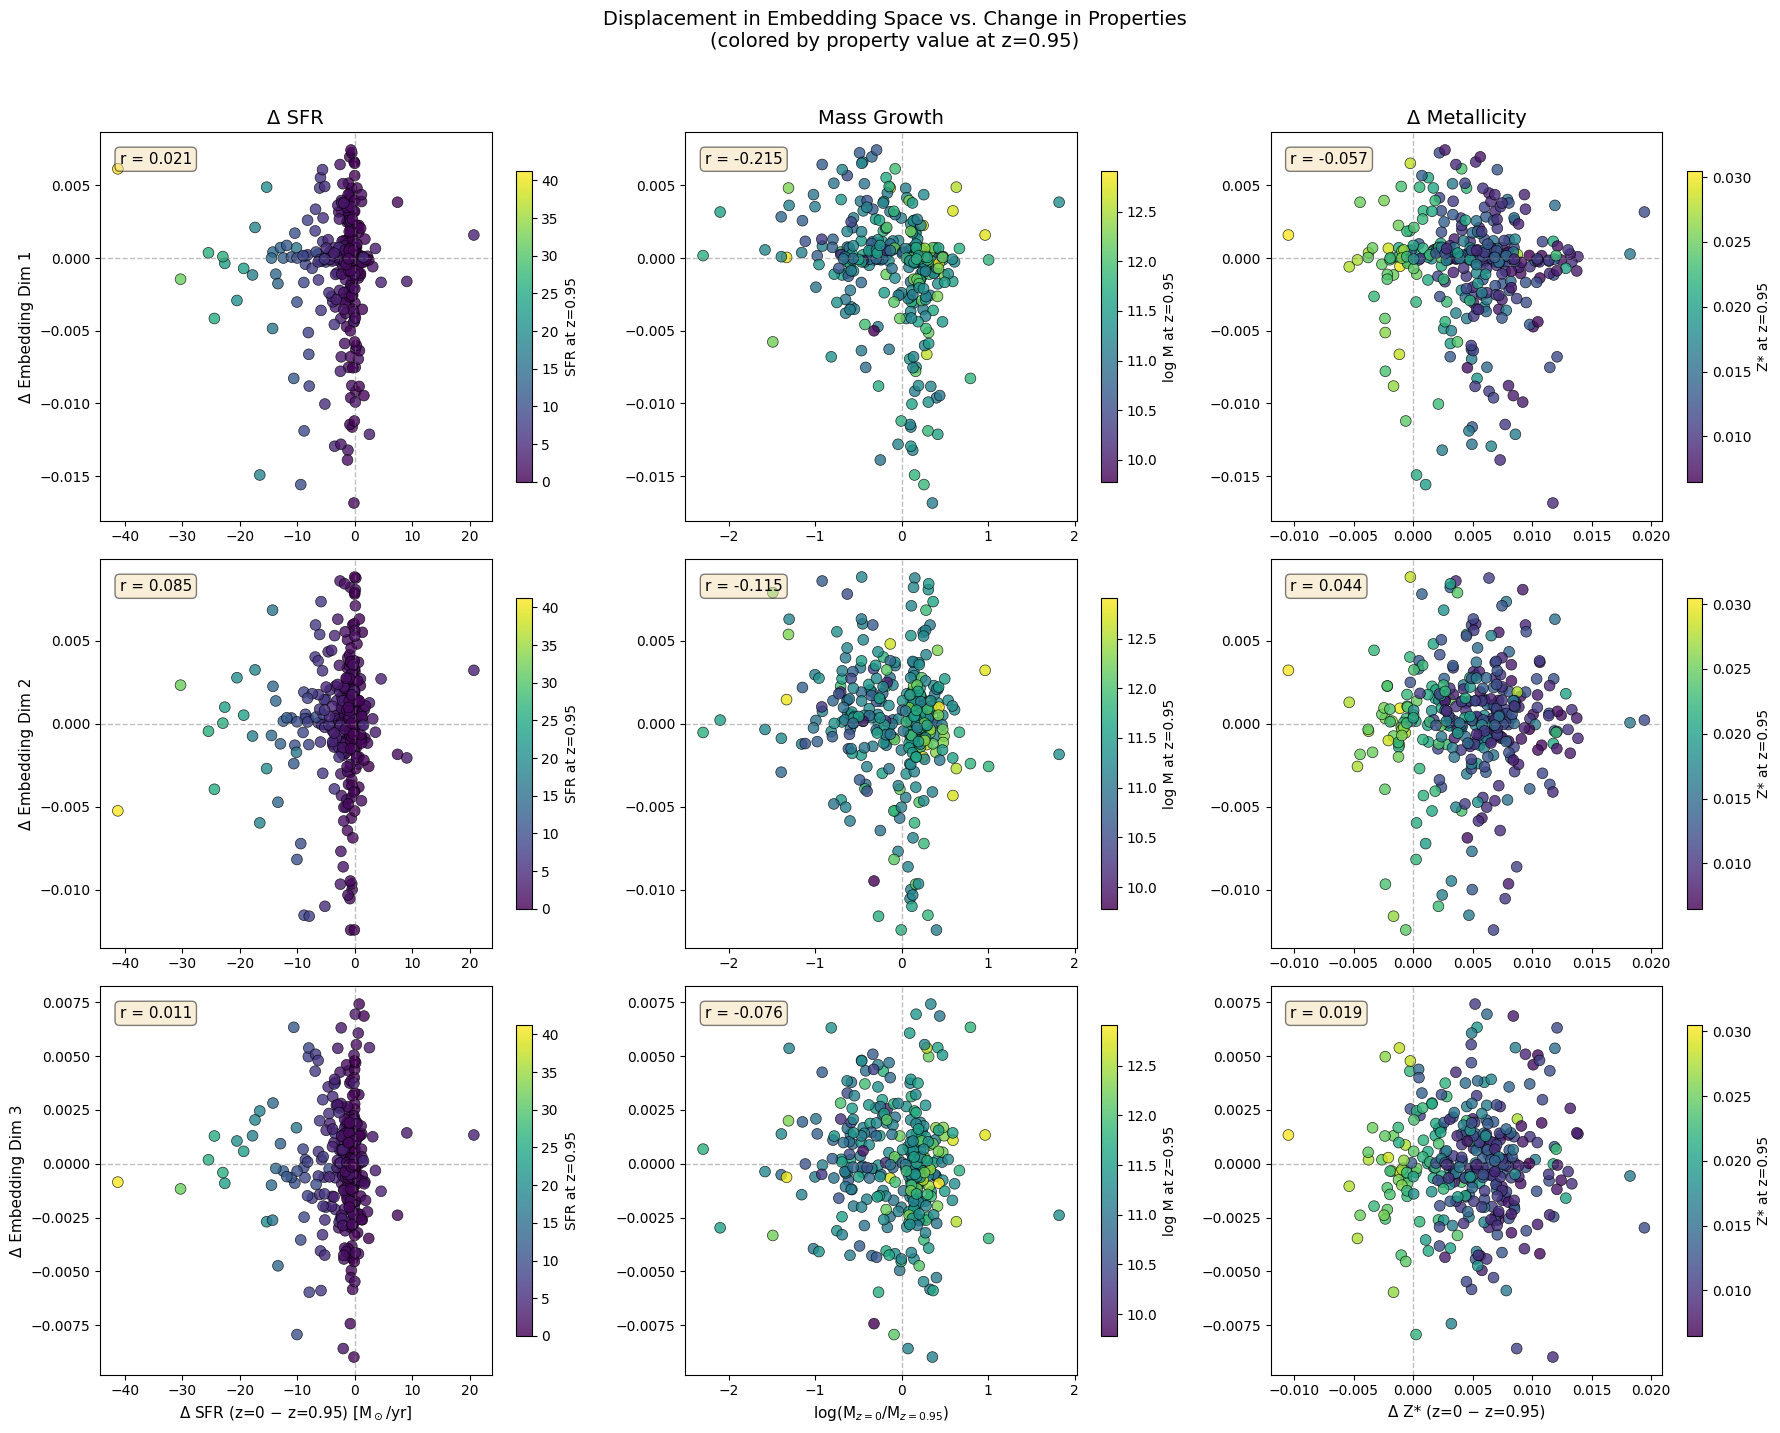

In [122]:
# Plot displacement along each embedding dimension vs. CHANGE in properties
# X-axis: Change in property (Δ SFR, log mass ratio, Δ metallicity)
# Y-axis: Signed displacement along each embedding dimension
# Colored by property value at z=0.95

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Properties: (name, delta_values, x_label, color_values, color_label)
properties = [
    ('Δ SFR', delta_sfr, 'Δ SFR (z=0 − z=0.95) [M$_\odot$/yr]', sfr_z095, 'SFR at z=0.95'),
    ('Mass Growth', log_mass_ratio, 'log(M$_{z=0}$/M$_{z=0.95}$)', np.log10(subhalo_mass_z095 * 1e10), 'log M at z=0.95'),
    ('Δ Metallicity', delta_metallicity, 'Δ Z* (z=0 − z=0.95)', star_metallicity_z095, 'Z* at z=0.95')
]

for row, dim in enumerate([0, 1, 2]):
    disp_dim = displacement[:, dim]
    
    for col, (prop_name, delta_vals, xlabel, color_vals, clabel) in enumerate(properties):
        ax = axes[row, col]
        
        valid = ~np.isnan(delta_vals) & ~np.isnan(color_vals) & ~np.isinf(delta_vals)
        
        sc = ax.scatter(delta_vals[valid], disp_dim[valid], s=60, alpha=0.8, 
                        c=color_vals[valid], cmap='viridis', edgecolors='k', linewidths=0.5)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_xlabel(xlabel if row == 2 else '', fontsize=11)
        ax.set_ylabel(f'Δ Embedding Dim {dim+1}' if col == 0 else '', fontsize=11)
        
        if row == 0:
            ax.set_title(prop_name, fontsize=14)
        
        # Add colorbar with label
        cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
        cbar.set_label(clabel, fontsize=10)
        
        # Add correlation coefficient (displacement vs change in property)
        if np.sum(valid) > 2:
            corr = np.corrcoef(delta_vals[valid], disp_dim[valid])[0, 1]
            ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Displacement in Embedding Space vs. Change in Properties\n(colored by property value at z=0.95)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

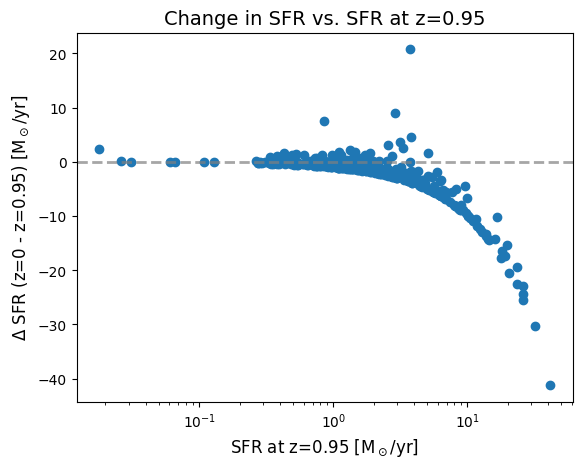

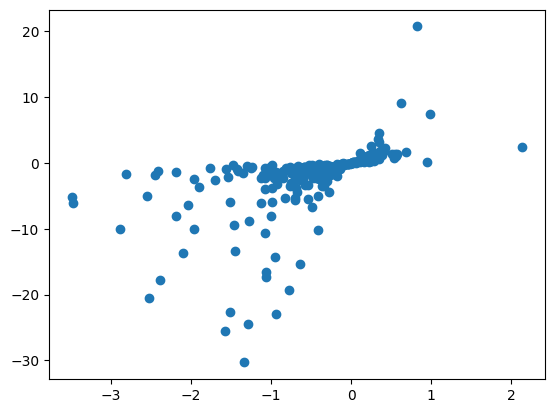

In [123]:
plt.plot( sfr_z095, delta_sfr[valid], 'o')
plt.xlabel('SFR at z=0.95 [M$_\odot$/yr]', fontsize=12 )
plt.ylabel('Δ SFR (z=0 - z=0.95) [M$_\odot$/yr]', fontsize=12)
plt.xscale('log')
plt.title('Change in SFR vs. SFR at z=0.95', fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=2, alpha=0.7)
plt.show()

plt.plot(log_sfr_ratio, delta_sfr, 'o')

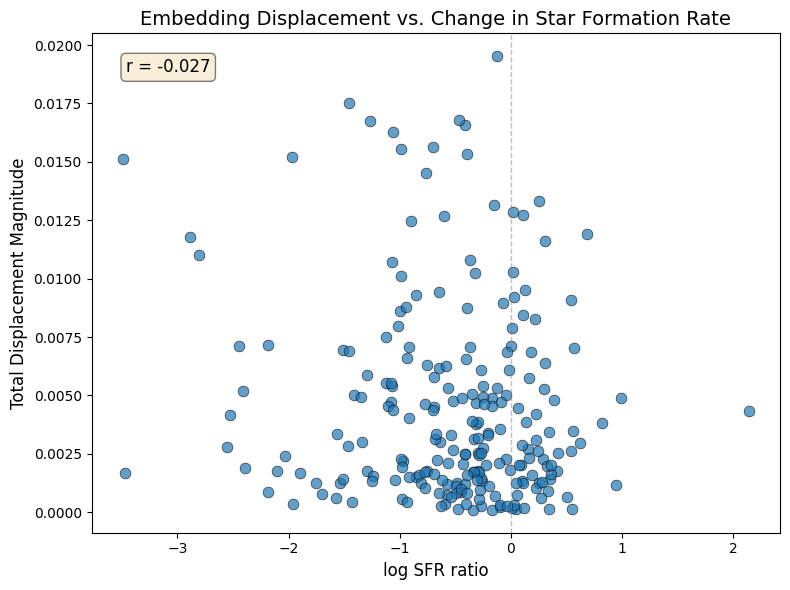

In [124]:
# Plot total displacement magnitude vs. change in SFR
fig, ax = plt.subplots(figsize=(8, 6))

valid = ~np.isnan(delta_sfr)

sc = ax.scatter(log_sfr_ratio[valid], displacement_magnitude[valid], s=60, alpha=0.7, 
                c='tab:blue', edgecolors='k', linewidths=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('log SFR ratio', fontsize=12)
ax.set_ylabel('Total Displacement Magnitude', fontsize=12)
ax.set_title('Embedding Displacement vs. Change in Star Formation Rate', fontsize=14)

# Add correlation coefficient
if np.sum(valid) > 2:
    corr = np.corrcoef(delta_sfr[valid], displacement_magnitude[valid])[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=12, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

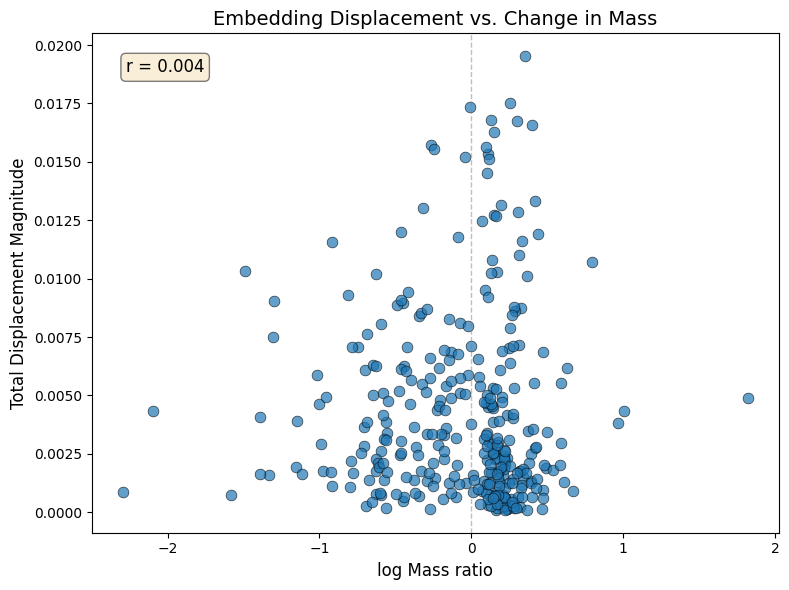

In [127]:
# Plot total displacement magnitude vs. change in SFR
fig, ax = plt.subplots(figsize=(8, 6))


sc = ax.scatter(log_mass_ratio, displacement_magnitude, s=60, alpha=0.7, 
                c='tab:blue', edgecolors='k', linewidths=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('log Mass ratio', fontsize=12)
ax.set_ylabel('Total Displacement Magnitude', fontsize=12)
ax.set_title('Embedding Displacement vs. Change in Mass', fontsize=14)

# Add correlation coefficient
if np.sum(valid) > 2:
    corr = np.corrcoef(log_mass_ratio, displacement_magnitude)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=12, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()